In [1]:
import pandas as pd

# CSV File Load
file_path = "Crop_Yield.csv"  
df = pd.read_csv(file_path)

print("Columns in Dataset:")
print(df.columns.tolist(), "\n")

print("Rows in Dataset:")
print(df.shape[0], "\n")

print("Crop names: Crop Quantity")
print(df["Crop"].value_counts(), "\n")


Columns in Dataset:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'] 

Rows in Dataset:
19689 

Crop names: Crop Quantity
Crop
Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB  # Not ideal for regression but included
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Load Dataset
df = pd.read_csv("Crop_Yield.csv")

# Define required columns
col = ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
df = df[col]

# Handle missing values
df.ffill(inplace=True)

# Features and Target
X = df.drop(columns=['Yield'])  # Features
y = df['Yield']  # Target

# One-Hot Encoding for categorical variables & Standard Scaling for numerical
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('OneHotEncode', ohe, ['Crop', 'Season', 'State']),
        ('Scale', scaler, ['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide'])
    ],
    remainder='passthrough'
)

# Transform Features
X = preprocessor.fit_transform(X)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

### **1. Decision Tree Regressor**
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
y_dt_pred = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, y_dt_pred)
dt_mae = mean_absolute_error(y_test, y_dt_pred)
D_accuracy_DT = dt_r2 * 100

print("\nDecision Tree Regressor:")
print(f"R-squared (R²): {dt_r2:.2f}")
print(f"Mean Absolute Error (MAE): {dt_mae:.2f}")
print(f"Decision Tree Accuracy (D_accuracy_DT): {D_accuracy_DT:.2f}%")

### **2. Random Forest Regressor**
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_rf_pred)
rf_mae = mean_absolute_error(y_test, y_rf_pred)
D_accuracy_RF = rf_r2 * 100

print("\nRandom Forest Regressor:")
print(f"R-squared (R²): {rf_r2:.2f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Random Forest Accuracy (D_accuracy_RF): {D_accuracy_RF:.2f}%")

### **3. Support Vector Regressor (SVM)**
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)
y_svm_pred = svm_model.predict(X_test)

svm_r2 = r2_score(y_test, y_svm_pred)
svm_mae = mean_absolute_error(y_test, y_svm_pred)
D_accuracy_SVM = svm_r2 * 100

print("\nSupport Vector Regressor (SVM):")
print(f"R-squared (R²): {svm_r2:.2f}")
print(f"Mean Absolute Error (MAE): {svm_mae:.2f}")
print(f"SVM Accuracy (D_accuracy_SVM): {D_accuracy_SVM:.2f}%")

### **4. K-Nearest Neighbors (KNN) Regressor**
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)

knn_r2 = r2_score(y_test, y_knn_pred)
knn_mae = mean_absolute_error(y_test, y_knn_pred)
D_accuracy_KNN = knn_r2 * 100

print("\nK-Nearest Neighbors Regressor:")
print(f"R-squared (R²): {knn_r2:.2f}")
print(f"Mean Absolute Error (MAE): {knn_mae:.2f}")
print(f"KNN Accuracy (D_accuracy_KNN): {D_accuracy_KNN:.2f}%")

### **5. Naïve Bayes (Not Recommended for Regression)**
from sklearn.linear_model import BayesianRidge

# Bayesian Ridge Regression (Alternative to Naïve Bayes for Regression)
br_model = BayesianRidge()
br_model.fit(X_train, y_train)
y_br_pred = br_model.predict(X_test)

br_r2 = r2_score(y_test, y_br_pred)
br_mae = mean_absolute_error(y_test, y_br_pred)
D_accuracy_BR = br_r2 * 100

print("\nBayesian Ridge Regression:")
print(f"R-squared (R²): {br_r2:.2f}")
print(f"Mean Absolute Error (MAE): {br_mae:.2f}")
print(f"Bayesian Ridge Accuracy (D_accuracy_BR): {D_accuracy_BR:.2f}%")




Decision Tree Regressor:
R-squared (R²): 0.97
Mean Absolute Error (MAE): 10.11
Decision Tree Accuracy (D_accuracy_DT): 97.12%

Random Forest Regressor:
R-squared (R²): 0.98
Mean Absolute Error (MAE): 9.60
Random Forest Accuracy (D_accuracy_RF): 97.99%

Support Vector Regressor (SVM):
R-squared (R²): -0.00
Mean Absolute Error (MAE): 76.84
SVM Accuracy (D_accuracy_SVM): -0.41%

K-Nearest Neighbors Regressor:
R-squared (R²): 0.95
Mean Absolute Error (MAE): 15.33
KNN Accuracy (D_accuracy_KNN): 95.27%

Bayesian Ridge Regression:
R-squared (R²): 0.81
Mean Absolute Error (MAE): 63.88
Bayesian Ridge Accuracy (D_accuracy_BR): 81.05%


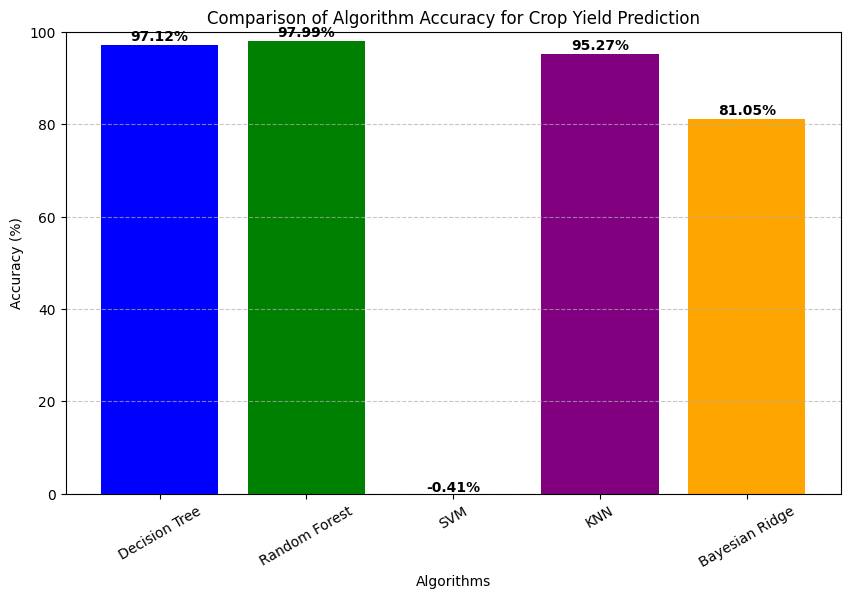

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy values from different models (Replace with actual values from your runs)
accuracy_values = {
    "Decision Tree": D_accuracy_DT,
    "Random Forest": D_accuracy_RF,  # Replace with actual variable
    "SVM": D_accuracy_SVM,  # Replace with actual variable
    "KNN": D_accuracy_KNN,  # Replace with actual variable
    "Bayesian Ridge": D_accuracy_BR,  # From your provided code
}

# Plot
plt.figure(figsize=(10, 6))
plt.bar(accuracy_values.keys(), accuracy_values.values(), color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Algorithm Accuracy for Crop Yield Prediction")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display accuracy values on top of bars
for i, v in enumerate(accuracy_values.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.show()


R-squared (R²): 0.97
Mean Absolute Error (MAE): 9.45
Decision Tree Accuracy (D_accuracy_DT): 97.27%


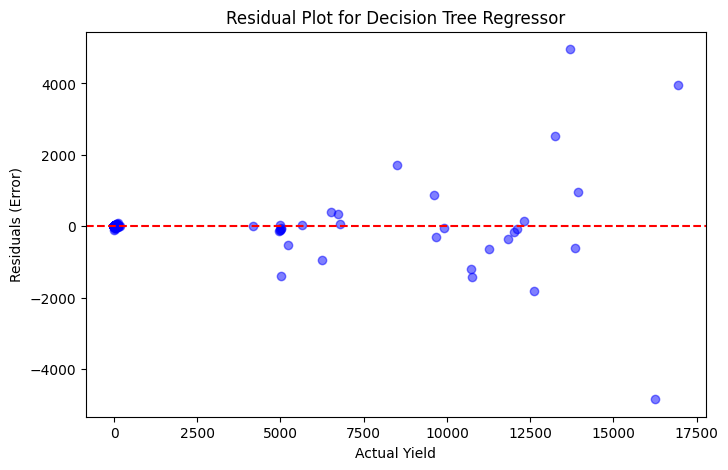

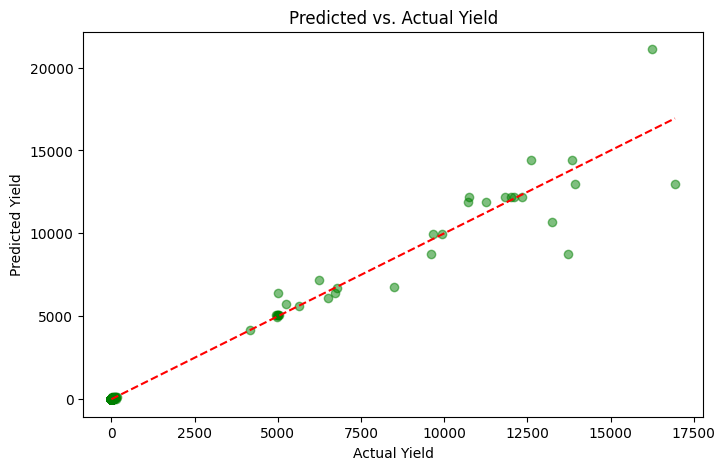

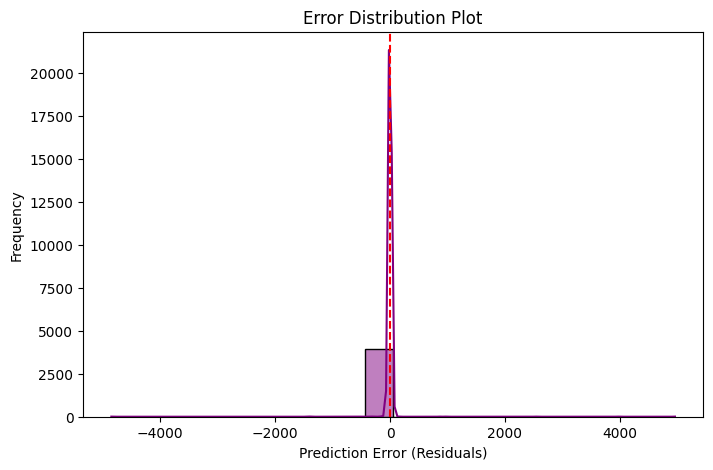

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load Dataset
df = pd.read_csv("Crop_Yield.csv")

# Define required columns
col = ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
df = df[col]

# Handle missing values
df.ffill(inplace=True)

# Features and Target
X = df.drop(columns=['Yield'])  # Features
y = df['Yield']  # Target

# One-Hot Encoding for categorical variables
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore') 
preprocessor = ColumnTransformer(
    transformers=[('OneHotEncode', ohe, ['Crop', 'Season', 'State'])],  
    remainder='passthrough'
)

# Transform Features
X = preprocessor.fit_transform(X)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Initialize Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth=10, random_state=42)

# Train Model
dtr.fit(X_train, y_train)

# Predictions
y_pred = dtr.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
D_accuracy_DT = r2 * 100  

print(f"R-squared (R²): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Decision Tree Accuracy (D_accuracy_DT): {D_accuracy_DT:.2f}%")

# ---------------------- PLOTS ----------------------

# ✅ Residual Plot (Actual - Predicted)
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, color="blue", alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Actual Yield")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot for Decision Tree Regressor")
plt.show()

# ✅ Scatter Plot (Predicted vs Actual)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color="green", alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")  # Line of perfect prediction
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs. Actual Yield")
plt.show()

# ✅ Error Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True, color="purple")
plt.axvline(x=0, color="red", linestyle="--")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")
plt.title("Error Distribution Plot")
plt.show()
